# Neural A* — Baseline and Bottleneck Profile

**Run this on the compute server.** A GPU session is preferred but not required — the notebook
detects what is available and reports CPU and GPU numbers separately.

```bash
srun --gres=gpu:1 --time=03:00:00 --mem=16G --pty bash
conda activate fpga_hw2       # or any env with torch + numpy + matplotlib
jupyter lab --no-browser --ip=0.0.0.0 --port=XXXX
```

### What this notebook is for

Before committing the FPGA work to one architecture, three
answers, and all three are measurements rather than opinions:

1. **Does the provided checkpoint actually reproduce the paper's result?**
   If it does not, everything downstream is built on sand.
2. **Which stage is the bottleneck — the CNN or the search?** The project
   proposal assumes the search is. That assumption decides whether this is a
   FINN project or a custom-HLS project, and it has never been measured.
3. **How big does the hardware have to be?** Peak open-list occupancy sizes the
   priority queue; the observed range of `f` sizes the fixed-point format.
   Nobody publishes these numbers because nobody else needed them.

Section 7 is the one that matters most. Everything before it exists to make
section 7 trustworthy.

## 0. Environment

In [1]:
import sys, os, time, platform, subprocess
import numpy as np

print(f"python  : {sys.version.split()[0]}  ({platform.platform()})")
print(f"numpy   : {np.__version__}")

import torch
print(f"torch   : {torch.__version__}")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    print(f"gpu     : {torch.cuda.get_device_name(0)}")
else:
    print("gpu     : none — CPU-only run. Timings in section 7 will still be "
          "meaningful, but the GPU comparison will be skipped.")
print(f"device  : {DEVICE}")

python  : 3.10.20  (Linux-5.15.0-181-generic-x86_64-with-glibc2.35)
numpy   : 1.26.4
torch   : 2.5.1+cu121
gpu     : NVIDIA GeForce RTX 2080 Ti
device  : cuda


## 1. Code and data

Two things have to be on disk:

- **`neural_astar_core/`** — the project package. Upload it next to this notebook.
- **`mazes_032_moore_c8.npz`** — the dataset the shipped checkpoint was trained on.

The dataset is *committed* into the `planning-datasets` repository, so there is
nothing to generate. The cell below clones it if the `.npz` is not already
present. `all_064_moore_c16.npz` comes along for free and gives us a 64×64
size-scaling axis in section 7.

In [2]:
from pathlib import Path
import fetch_data

DATA_32 = Path("mazes_032_moore_c8.npz")
DATA_64 = Path("all_064_moore_c16.npz")

# Same script as the shell entry point -- one way to get data, not two.
fetch_data.main()

for p in [DATA_32, DATA_64]:
    print(f"{'OK  ' if p.exists() else 'MISS'} {p}")

assert Path("neural_astar_core").is_dir(), (
    "neural_astar_core/ not found. It must sit in the SAME directory Jupyter "
    "opened this notebook from -- check os.getcwd().")
assert list(Path("model").glob("**/*.ckpt")), (
    "no .ckpt under model/ -- copy the model/ tree from the neural-astar repo "
    "into this directory.")
print("\nsetup OK")

All datasets already present:
  mazes_032_moore_c8.npz  (1,542 KB)
  all_064_moore_c16.npz  (24,908 KB)
OK   mazes_032_moore_c8.npz
OK   all_064_moore_c16.npz

setup OK


### A note on the two dataset conventions that bite people

- `map_design` is **1.0 for free space**, 0.0 for walls. Not the other way round.
- `opt_dist` is **negative**: the goal is `-0.0` and cells grow more negative
  with distance. Unreachable cells (every wall, plus sealed pockets) are
  `-1024.0`. The loader flips the sign so `GridProblem.optimal_cost()` returns a
  positive number.

`opt_dist` is used as ground truth for path optimality rather than trusting
vanilla A* to be right, which is a slightly stronger check than upstream makes.

## 2. Load the encoder

In [3]:
from neural_astar_core import (
    sample_problems, MazeDataset,
    VanillaAStarPlanner, NeuralAStarPlanner,
    load_encoder_from_checkpoint, evaluate,
    astar_search, upstream_pq_astar,
)

CKPT_DIR = "model/mazes_032_moore_c8/lightning_logs/"

encoder = load_encoder_from_checkpoint(CKPT_DIR, device=DEVICE)
print(f"loaded : {encoder.checkpoint_path}")
print(f"params : {encoder.num_parameters():,}")
print(f"MACs   : {encoder.macs_per_map(32, 32) / 1e6:,.0f} M  per 32x32 map")
print(f"         {encoder.macs_per_map(64, 64) / 1e6:,.0f} M  per 64x64 map")

# What that means against the target board.
PYNQ_Z2 = {"LUT": 53200, "FF": 106400, "BRAM_36K": 140, "DSP": 220}
bram_bits = PYNQ_Z2["BRAM_36K"] * 36 * 1024
for wbits in (8, 4, 2):
    need = encoder.num_parameters() * wbits
    print(f"weights @ {wbits}-bit: {need/8/1024:7.0f} KB  "
          f"= {100*need/bram_bits:5.1f}% of PYNQ-Z2 BRAM")

loaded : model/mazes_032_moore_c8/lightning_logs/version_0/checkpoints/epoch=33-step=272.ckpt
params : 391,395
MACs   : 399 M  per 32x32 map
         1,597 M  per 64x64 map
weights @ 8-bit:     382 KB  =  60.7% of PYNQ-Z2 BRAM
weights @ 4-bit:     191 KB  =  30.3% of PYNQ-Z2 BRAM
weights @ 2-bit:      96 KB  =  15.2% of PYNQ-Z2 BRAM


## 3. Sanity check: the search matches upstream exactly

The `astar_search` implementation stores `g` explicitly and computes `f = r·g + (1−r)·h`.
Upstream's `pq_astar` never stores `g` — it rolls the update forward
algebraically. The two differ by the constant `(1−r)·h(start)`, which shifts
every `f` equally and so cannot change the pop order.

That is an argument. This is a test. If it ever fails, the reference model has
drifted from the implementation being accelerated.

In [4]:
check_set = sample_problems(str(DATA_32), "test", 25, seed=0)
ones = np.ones((32, 32))

mismatches, suboptimal = 0, 0
for p in check_set:
    mine = astar_search(p, ones)
    theirs = upstream_pq_astar(p, ones)
    if (mine.success != theirs.success
            or mine.path_length() != theirs.path_length()
            or mine.num_expansions != theirs.num_expansions):
        mismatches += 1
    # vanilla A* on a unit-cost map should hit the dataset's true optimum
    if abs(mine.path_cost(ones.ravel()) - p.optimal_cost()) > 1e-9:
        suboptimal += 1

print(f"upstream-equivalence mismatches : {mismatches} / {len(check_set)}")
print(f"vanilla paths off true optimum  : {suboptimal} / {len(check_set)}")
assert mismatches == 0 and suboptimal == 0, "golden model is not golden"
print("\nreference search validated")

upstream-equivalence mismatches : 0 / 25
vanilla paths off true optimum  : 0 / 25

reference search validated


## 4. Randomised problem sets

The datasets ship maps and goals but **no start positions** — upstream draws one
at random every time `__getitem__` is called, so every epoch sees different
problems on the same maps.

That behaviour is kept, but under explicit control. `seed=None` gives a fresh draw on
every run, which suits the case where each run should be an independent sample.
The seed that was actually used is always recorded on the `ProblemSet`, so any
surprising result can be replayed exactly. Set `SEED` below to an integer when
a run must be reproducible.

Starts are drawn from the far 55% of reachable cells by true distance, matching
upstream. A start next to the goal would tell us nothing about search efficiency.

In [5]:
SEED = None      # None = fresh random draw each run; set an int to reproduce
N_PROBLEMS = 100

problems = sample_problems(str(DATA_32), "test", N_PROBLEMS, seed=SEED)
print(problems.describe())
print(f"\nreplay this exact set with:  sample_problems(..., seed={problems.seed})")

100 problems | 32x32 grid | split=test | seed=10359069 | source=mazes_032_moore_c8.npz

replay this exact set with:  sample_problems(..., seed=10359069)


## 5. One problem, end to end

The plot below separates three things that are easy to conflate:

| colour | meaning |
|---|---|
| pale yellow | **generated** — pushed onto the open list, `f` computed, never popped |
| green | **expanded** — popped, closed, all 8 neighbours generated |
| red | the returned **path** |

Drawing only "expanded" and then painting the path on top is misleading. On an
open map Chebyshev distance is an almost *exact* cost-to-go, so A\* walks nearly
straight to the goal and the expanded set collapses onto the path — which looks
like the algorithm never explored anything. It did: it evaluated all 8
neighbours of every expanded node. It just never needed to pop most of them.

The pale-yellow halo is that frontier. It is also the more honest hardware work
metric: every generated node costs a cost-map read, a heuristic read, an `f`
computation and a queue insertion, whether or not it is ever expanded.

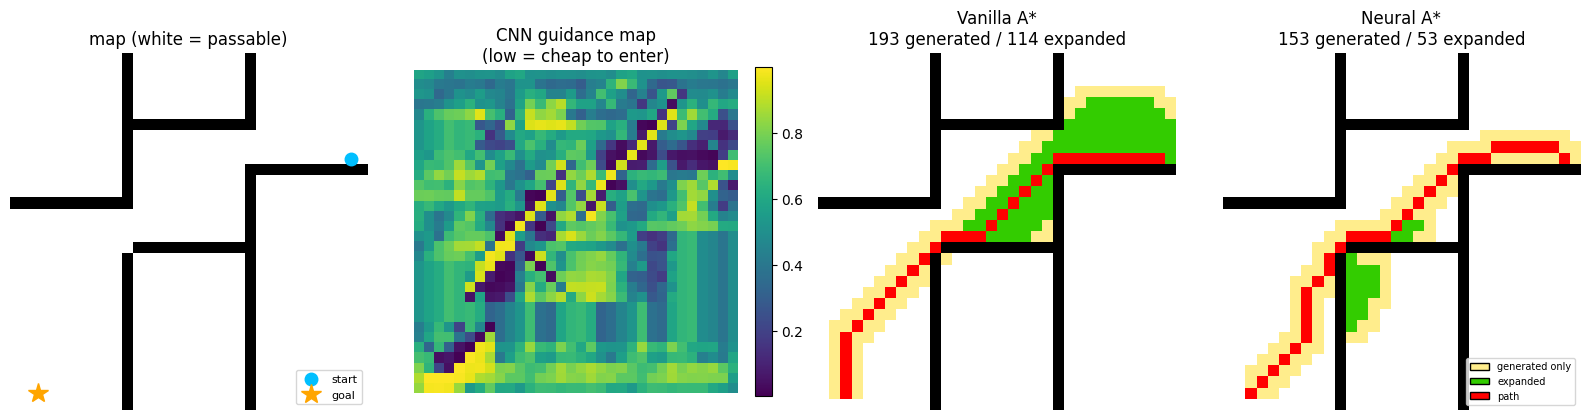

            generated  expanded   path  peak open
vanilla           193       114     34         80
neural            153        53     34        101

generated >= expanded >= path, always. If expanded == path on some map,
that is not a bug -- it means the heuristic was exact and A* never had to
back out of a wrong turn. Try another problem index to see a harder one.


In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

vanilla = VanillaAStarPlanner()
neural  = NeuralAStarPlanner(encoder, device=DEVICE)

p = problems[0]
r_van = vanilla.plan(p)
r_neu = neural.plan(p)


def render(problem, result):
    """Three-tier search render: generated / expanded / path."""
    h, w = problem.height, problem.width
    canvas = np.stack([problem.obstacle_map] * 3, axis=-1).astype(float)
    canvas[result.frontier_map(h, w)] = [1.00, 0.93, 0.55]   # generated only
    canvas[result.closed_map(h, w)]   = [0.20, 0.80, 0.00]   # expanded
    canvas[result.path_map(h, w)]     = [1.00, 0.00, 0.00]   # path
    return canvas


fig, ax = plt.subplots(1, 4, figsize=(16, 4.4))

ax[0].imshow(p.obstacle_map, cmap="gray")
sr, sc = p.to_rc(p.start); gr, gc = p.to_rc(p.goal)
ax[0].plot(sc, sr, "o", color="deepskyblue", ms=9, label="start")
ax[0].plot(gc, gr, "*", color="orange", ms=15, label="goal")
ax[0].set_title("map (white = passable)"); ax[0].legend(loc="lower right", fontsize=8)

im = ax[1].imshow(r_neu.cost_map, cmap="viridis")
ax[1].set_title("CNN guidance map\n(low = cheap to enter)")
plt.colorbar(im, ax=ax[1], fraction=0.046)

for a, res, name in [(ax[2], r_van, "Vanilla A*"), (ax[3], r_neu, "Neural A*")]:
    s = res.search
    a.imshow(render(p, s))
    a.set_title(f"{name}\n{s.num_generated} generated / "
                f"{s.num_expansions} expanded")

ax[3].legend(handles=[
    Patch(facecolor=(1.00, 0.93, 0.55), edgecolor="k", label="generated only"),
    Patch(facecolor=(0.20, 0.80, 0.00), edgecolor="k", label="expanded"),
    Patch(facecolor=(1.00, 0.00, 0.00), edgecolor="k", label="path"),
], loc="lower right", fontsize=7)

for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

print(f"{'':10} {'generated':>10} {'expanded':>9} {'path':>6} {'peak open':>10}")
for name, res in [("vanilla", r_van), ("neural", r_neu)]:
    s = res.search
    print(f"{name:10} {s.num_generated:10d} {s.num_expansions:9d} "
          f"{s.path_length():6d} {s.peak_open_size:10d}")

print("\ngenerated >= expanded >= path, always. If expanded == path on some map,")
print("that is not a bug -- it means the heuristic was exact and A* never had to")
print("back out of a wrong turn. Try another problem index to see a harder one.")

### If the search looks suspiciously direct

Pick a harder instance. `expanded == path` happens on open maps where Chebyshev
is exact; it is correct A\* behaviour, not a short-circuit. The cell below finds
the problem in the set where vanilla A\* had to work hardest, which is the more
instructive picture.

easiest problem: index 54 (17 expansions)
hardest problem: index 1 (433 expansions)


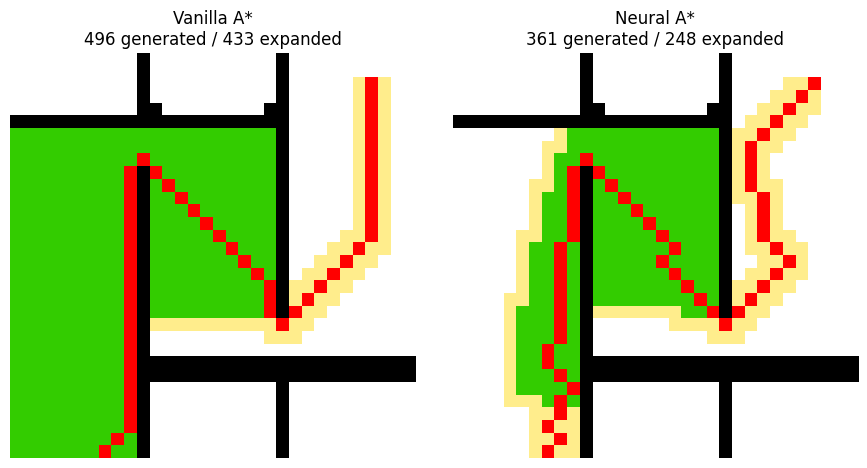

Neural A* expanded 43% fewer nodes on this problem.


In [7]:
work = [(vanilla.plan(q).search.num_expansions, i) for i, q in enumerate(problems)]
work.sort()
hardest = work[-1][1]
print(f"easiest problem: index {work[0][1]} ({work[0][0]} expansions)")
print(f"hardest problem: index {hardest} ({work[-1][0]} expansions)")

q = problems[hardest]
qv, qn = vanilla.plan(q), neural.plan(q)

fig, ax = plt.subplots(1, 2, figsize=(9, 4.6))
for a, res, name in [(ax[0], qv, "Vanilla A*"), (ax[1], qn, "Neural A*")]:
    s = res.search
    a.imshow(render(q, s))
    a.set_title(f"{name}\n{s.num_generated} generated / {s.num_expansions} expanded")
    a.axis("off")
plt.tight_layout(); plt.show()

reduction = 1 - qn.search.num_expansions / max(qv.search.num_expansions, 1)
print(f"Neural A* expanded {reduction:.0%} fewer nodes on this problem.")

## 6. Does the checkpoint reproduce the paper?

Three metrics, matching the paper so the numbers are directly comparable:

- **`p_opt`** — fraction of Neural A* paths as short as vanilla A*'s.
- **`p_exp`** — mean reduction in node expansions vs vanilla A*, clipped at zero.
  This is what the network is actually trained to improve.
- **`h_mean`** — harmonic mean of the two. Harmonic, so that being fast-but-wrong
  or correct-but-slow both score badly.

In [8]:
report = evaluate(problems, vanilla, neural)
print(report.summary())

problems evaluated      : 100
success (vanilla / NA*) : 100.0% / 100.0%
p_opt                   : 0.830
p_exp (clipped, paper)  : 0.445
p_exp (unclipped)       : 0.421
h_mean                  : 0.579

p_gen (clipped)         : 0.239
p_gen (unclipped)       : 0.206
Neural worse (expanded) : 12.0% of problems
Neural worse (generated): 20.0% of problems
worst single regression : -104.2%

mean encode time        : 1.12 ms
mean search time        : 0.84 ms
CNN share of runtime    : 57.0%

peak open list (max)    : 124 entries
max f observed          : 16.07


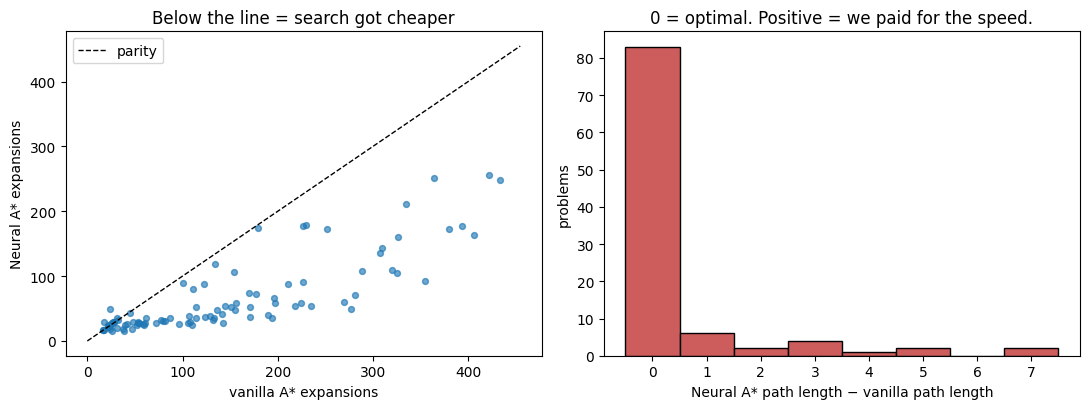

In [9]:
arr = report.to_arrays()
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

lim = max(arr["expansions_baseline"].max(), arr["expansions_neural"].max()) * 1.05
ax[0].scatter(arr["expansions_baseline"], arr["expansions_neural"], s=18, alpha=0.65)
ax[0].plot([0, lim], [0, lim], "k--", lw=1, label="parity")
ax[0].set_xlabel("vanilla A* expansions"); ax[0].set_ylabel("Neural A* expansions")
ax[0].set_title("Below the line = search got cheaper"); ax[0].legend()

diff = arr["path_length_neural"] - arr["path_length_baseline"]
ax[1].hist(diff, bins=range(int(diff.min()), int(diff.max()) + 2), align="left",
           color="indianred", edgecolor="black")
ax[1].set_xlabel("Neural A* path length − vanilla path length")
ax[1].set_ylabel("problems")
ax[1].set_title("0 = optimal. Positive = the speed was paid for.")

plt.tight_layout(); plt.show()

## 7. Where does the time actually go?

**This is the section the FPGA plan depends on.**

The project proposal assumes the search is the bottleneck and puts it on the
FPGA while leaving the CNN on the host. That assumption has never been checked.
If it is wrong, this would mean building a hardware accelerator for a stage that
barely registers in the profile.

Four measurements are taken, because the answer could plausibly depend on any of them:
CPU vs GPU, batch=1 vs batched, and 32×32 vs 64×64.

The batched number is included because that is how a GPU is usually benchmarked
— but it is *not* the deployment case. A robot plans one path at a time. Report
both; do not quote whichever flatters the conclusion.

In [10]:
def profile(dataset_path, n=40, device="cpu", seed=1234):
    ps = sample_problems(str(dataset_path), "test", n, seed=seed)
    enc = load_encoder_from_checkpoint(CKPT_DIR, device=device)
    van = VanillaAStarPlanner()
    neu = NeuralAStarPlanner(enc, device=device)

    # warm up: first call pays for lazy CUDA init and cuDNN autotuning
    for _ in range(3):
        neu.plan(ps[0])

    rep = evaluate(ps, van, neu)
    t = rep.timing_split()

    _, batch_seconds = neu.encode_batch(list(ps.problems))
    t["encode_seconds_batched"] = batch_seconds / len(ps)
    t["size"] = f"{ps[0].height}x{ps[0].width}"
    t["device"] = device
    t["p_exp"] = rep.p_exp
    t["report"] = rep
    return t


runs = []
for path in [DATA_32, DATA_64]:
    for dev in (["cpu", "cuda"] if DEVICE == "cuda" else ["cpu"]):
        print(f"profiling {path.name} on {dev} ...")
        runs.append(profile(path, n=40, device=dev))
print("done")

profiling mazes_032_moore_c8.npz on cpu ...
profiling mazes_032_moore_c8.npz on cuda ...
profiling all_064_moore_c16.npz on cpu ...
profiling all_064_moore_c16.npz on cuda ...
done


In [11]:
hdr = (f"{'size':>7} {'dev':>5} {'CNN b=1':>10} {'CNN batched':>12} "
       f"{'search':>9} {'CNN share':>10} {'p_exp':>7}")
print(hdr); print("-" * len(hdr))
for t in runs:
    print(f"{t['size']:>7} {t['device']:>5} "
          f"{t['encode_seconds']*1e3:9.2f}ms "
          f"{t['encode_seconds_batched']*1e3:11.2f}ms "
          f"{t['search_seconds']*1e3:8.2f}ms "
          f"{t['encode_fraction']:9.1%} "
          f"{t['p_exp']:7.3f}")

print("\n'CNN share' is the fraction of single-problem wall-clock spent in the "
      "network.\nThat number decides the architecture.")

   size   dev    CNN b=1  CNN batched    search  CNN share   p_exp
------------------------------------------------------------------
  32x32   cpu     15.03ms       14.15ms     1.46ms     91.1%   0.441
  32x32  cuda      1.04ms        0.34ms     0.90ms     53.7%   0.441
  64x64   cpu     45.02ms       59.79ms     2.77ms     94.2%   0.539
  64x64  cuda      1.09ms        0.37ms     2.03ms     34.8%   0.539

'CNN share' is the fraction of single-problem wall-clock spent in the network.
That number decides the architecture.


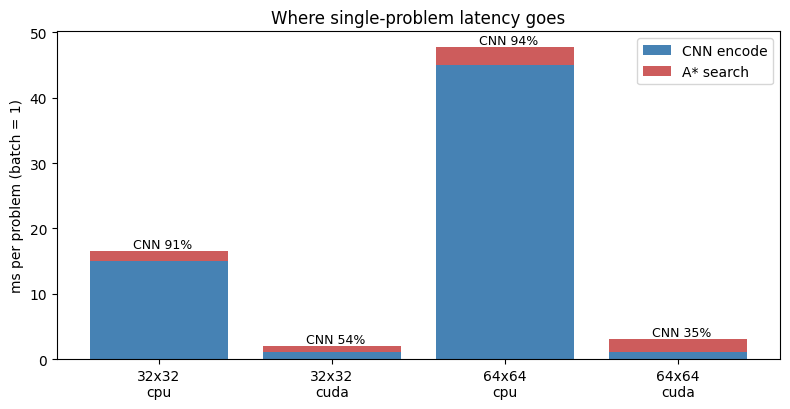

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.2))
labels = [f"{t['size']}\n{t['device']}" for t in runs]
enc_ms = [t["encode_seconds"] * 1e3 for t in runs]
sea_ms = [t["search_seconds"] * 1e3 for t in runs]
x = np.arange(len(runs))

ax.bar(x, enc_ms, label="CNN encode", color="steelblue")
ax.bar(x, sea_ms, bottom=enc_ms, label="A* search", color="indianred")
for i, t in enumerate(runs):
    ax.text(i, enc_ms[i] + sea_ms[i], f"  CNN {t['encode_fraction']:.0%}",
            ha="center", va="bottom", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("ms per problem (batch = 1)")
ax.set_title("Where single-problem latency goes")
ax.legend()
plt.tight_layout(); plt.show()

### Read the table before writing any HLS

If the CNN share is high and stays high as the map grows, then the search is not
the bottleneck and accelerating it in isolation cannot produce a meaningful
end-to-end speedup — Amdahl's law caps the win at whatever fraction the search
occupies. In that case the CNN is the target, which means FINN, which is the
flow used previously.

That does not make the search accelerator worthless; it makes it a *second*
contribution rather than the headline. Write down what the table actually says
here, including the numbers, so the report is arguing from measurement.

## 8. How big does the hardware have to be?

Three numbers, none of which appear in any paper because nobody else needed them.

**Peak open-list occupancy** sizes the priority queue — the genuinely hard part
of an A* accelerator. If it stays in the low hundreds, a register-array PQ with
a parallel compare tree is affordable and gives single-cycle pop. If it runs to
thousands, a bucket queue is needed instead: an occupancy bitmap plus
leading-zero-detect, which is exact and much cheaper but requires `f` to be
bounded and quantised.

**The range of `f`** sizes the integer part of the fixed-point format.

**The visited-set size** is the number that settles the Bloom filter question.

In [13]:
hw = report.hardware_stats()
num_nodes = problems[0].num_nodes

print(f"peak open list  : mean {hw['peak_open_neural_mean']:.0f}, "
      f"max {hw['peak_open_neural_max']:.0f} entries")
print(f"max expansions  : {hw['expansions_neural_max']:.0f}")
print(f"max f observed  : {hw['max_f_observed']:.2f}")
print()
print(f"visited set     : {num_nodes} nodes = {num_nodes} bits "
      f"= {num_nodes/8/1024:.2f} KB  ({100*num_nodes/(140*36*1024):.2f}% of "
      f"PYNQ-Z2 BRAM)")
print()
print("The visited set is an exact bit-vector indexed directly by the flat grid")
print("index. One BRAM, one cycle, zero false positives. A Bloom filter would be")
print("larger, slower, and occasionally wrong — and a false positive here means")
print("skipping a node that should have been expanded, so it costs path quality with no")
print("throughput bought in exchange. Section 9 says what to do about that.")

peak open list  : mean 83, max 124 entries
max expansions  : 256
max f observed  : 16.07

visited set     : 1024 nodes = 1024 bits = 0.12 KB  (0.02% of PYNQ-Z2 BRAM)

The visited set is an exact bit-vector indexed directly by the flat grid
index. One BRAM, one cycle, zero false positives. A Bloom filter would be
larger, slower, and occasionally wrong — and a false positive here means
skipping a node that should have been expanded, so it costs path quality with no
throughput bought in exchange. Section 9 says what to do about that.


In [14]:
from neural_astar_core.fixedpoint import sweep_precision, suggest_format, open_list_bits

BITS = (4, 6, 8, 10, 12, 16)
agg = {b: [] for b in BITS}

for p in list(problems)[:40]:
    cost, _ = neural.cost_map(p)
    for r in sweep_precision(p, cost, fractional_bits=BITS):
        agg[r.fractional_bits].append((r.expansion_ratio, r.path_matches))

print(f"{'frac bits':>10} {'expansions vs float':>20} {'worst':>8} {'path match':>12}")
print("-" * 54)
for b in BITS:
    ratios = [x[0] for x in agg[b]]
    match  = np.mean([x[1] for x in agg[b]])
    print(f"{b:>10} {np.mean(ratios):19.4f} {max(ratios):8.4f} {match:11.1%}")

print("\nExpansion ratio > 1.0 means precision loss made the search do MORE work.")
print("That failure is invisible to a correctness-only test: the path is still")
print("valid, the benefit is quietly lost the benefit of Neural A*.")

 frac bits  expansions vs float    worst   path match
------------------------------------------------------
         4              0.9911   1.0847       95.0%
         6              0.9992   1.0109      100.0%
         8              0.9982   1.0058      100.0%
        10              1.0000   1.0000      100.0%
        12              1.0000   1.0000      100.0%
        16              1.0000   1.0000      100.0%

Expansion ratio > 1.0 means precision loss made the search do MORE work.
That failure is invisible to a correctness-only test: the path is still
valid, the benefit is quietly lost the benefit of Neural A*.


In [15]:
CHOSEN_FRAC_BITS = 10   # adjust from the table above

fmt = suggest_format(hw["max_f_observed"], int(hw["expansions_neural_max"]),
                     CHOSEN_FRAC_BITS)
pq = open_list_bits(int(hw["peak_open_neural_max"]), fmt["total_bits"], num_nodes)

print("proposed fixed-point format")
for k, v in fmt.items():
    print(f"  {k:<22}: {v}")
print("\npriority queue storage")
for k, v in pq.items():
    print(f"  {k:<22}: {v}")

print(f"\nap_fixed<{fmt['total_bits']}, {fmt['integer_bits']}> "
      f"— the whole open list is {pq['total_bytes']} bytes.")
print("This is a small design. The constraint on this project is the CNN, not "
      "the search.")

proposed fixed-point format
  integer_bits          : 7
  fractional_bits       : 10
  total_bits            : 17
  max_representable     : 127
  resolution_micro      : 977
  max_expansions_seen   : 256

priority queue storage
  entries               : 124
  index_bits            : 10
  entry_bits            : 27
  total_bits            : 3348
  total_bytes           : 419

ap_fixed<17, 7> — the whole open list is 419 bytes.
This is a small design. The constraint on this project is the CNN, not the search.


## 9. What this means

Fill this in from the numbers above rather than from expectation — the point of
the notebook is that measurements are now available. Things to state explicitly:

1. **Reproduction.** Do `p_opt` / `p_exp` / `h_mean` match the paper closely
   enough to trust the checkpoint?
2. **Bottleneck.** What is the CNN's share of single-problem latency, and does
   it change with map size or device? What does Amdahl's law then cap a
   search-only accelerator at?
3. **Board requirement.** Weights at 8/4/2-bit against 140 BRAM-36K — does the
   full-width encoder fit a PYNQ-Z2, or must a narrower one be trained? This is
   the number that goes in the email to the TA.
4. **Search accelerator scale.** Peak open list and the chosen `ap_fixed` width.
   If the whole open list is a few hundred bytes, say so — it reframes the
   search engine as a cheap second contribution rather than the main event.
5. **Bloom filter.** The visited set is an exact bit-vector of `H*W` bits. State
   the measured size, and state the condition under which a Bloom filter would
   start to win (node IDs sparse enough that the dense bitmap no longer fits on
   chip) — which is the regime the cited paper targets, and is not
   the regime here.

Point 5 is a result, not a retreat. The grading criterion explicitly accepts
proving that a suggested improvement *does not* work as intended, and
"the crossover point was measured" is a stronger
contribution than forcing a technique into a problem that does not need it.